In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q xgboost imbalanced-learn

import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

PROCESSED_PATH = '/content/drive/MyDrive/Churn_Hackathon/data/processed/'

X_train = pd.read_csv(PROCESSED_PATH + 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_PATH + 'X_test.csv')
y_train = pd.read_csv(PROCESSED_PATH + 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_PATH + 'y_test.csv').squeeze()

print(f"✅ Data loaded: {X_train.shape}")

Mounted at /content/drive
✅ Data loaded: (5634, 32)


In [2]:
# Churn datasets are imbalanced (~26% churn) — SMOTE fixes this
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}


In [3]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False,
                                          eval_metric='logloss',
                                          random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🔄 Training: {name}...")
    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}

    print(f"✅ {name} — AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))


🔄 Training: Logistic Regression...
✅ Logistic Regression — AUC: 0.8270
              precision    recall  f1-score   support

      Stayed       0.87      0.77      0.82      1035
     Churned       0.51      0.68      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.78      0.74      0.75      1409


🔄 Training: Random Forest...
✅ Random Forest — AUC: 0.8219
              precision    recall  f1-score   support

      Stayed       0.86      0.80      0.83      1035
     Churned       0.54      0.64      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409


🔄 Training: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:06:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost — AUC: 0.8115
              precision    recall  f1-score   support

      Stayed       0.87      0.80      0.83      1035
     Churned       0.54      0.66      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



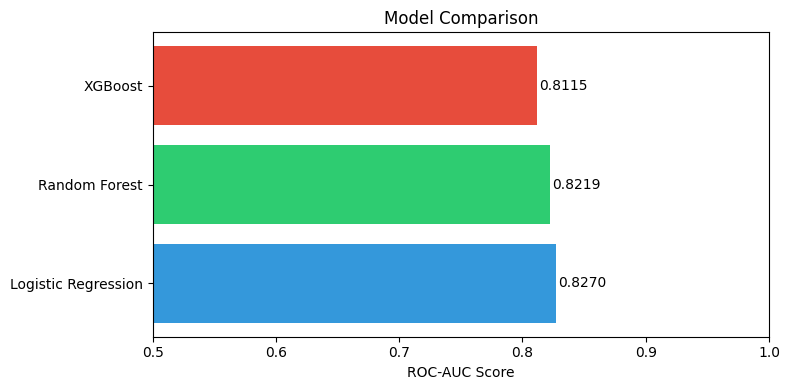


🏆 Best Model: Logistic Regression (AUC: 0.8270)


In [4]:
import matplotlib.pyplot as plt

# Compare AUC scores
names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]

plt.figure(figsize=(8, 4))
bars = plt.barh(names, aucs, color=['#3498db', '#2ecc71', '#e74c3c'])
plt.xlabel('ROC-AUC Score')
plt.title('Model Comparison')
plt.xlim(0.5, 1.0)

for bar, auc in zip(bars, aucs):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{auc:.4f}', va='center')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Churn_Hackathon/data/model_comparison.png', dpi=150)
plt.show()

# Pick the best model
best_name = max(results, key=lambda n: results[n]['auc'])
best_model = results[best_name]['model']
print(f"\n🏆 Best Model: {best_name} (AUC: {results[best_name]['auc']:.4f})")

In [5]:
MODEL_PATH = '/content/drive/MyDrive/Churn_Hackathon/data/processed/'

with open(MODEL_PATH + 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Also save model name for reference
with open(MODEL_PATH + 'best_model_name.txt', 'w') as f:
    f.write(best_name)

print(f"✅ Best model ({best_name}) saved!")

✅ Best model (Logistic Regression) saved!
